<h1><center>Laboratorio 6: ¿A cuanto la casa 🏡?</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Guillermo Cárdenas
- Nombre de alumno 2: Matias Carvajal


### **Link de repositorio de GitHub:** `https://github.com/Wiliwiliwili/MDS7202/labs/lab_6`


## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

### Objetivos principales del laboratorio

- Aplicar los conocimientos de preprocesamiento, feature extraction y regresión vistos hasta el momento
- Calcular, aplicar e interpretar métricas de regresión
- Mostrar comprensión sobre el fenómeno de sobreajuste y las implicancias que este tiene, así como formas de evitarlo


El laboratorio deberá ser desarrollado con las herramientas de scikit-learn, incluyendo el uso de pipelines

## Descripción del laboratorio.

Usted acaba de ser contratado por la gran empresa inmobiliaria chilena ***TasAi Ltda.*** Esta empresa maneja una parte importante de las propiedades de Santiago, y buscan aumentar sus ventas mediante un **modelo de pricing** que optimice el valor de venta de las propiedades. Para esto, le han encomendado la tarea de liderar un equipo multidisciplinario de analistas, científicos e ingenieros de datos para analizar datos de características de viviendas de santiago de Chile y sus precios y así poder predecir el valor de venta.

## 1. Pipeline predictivo

### 1.1 EDA [1 ptos]

Don ElIas, CEO de _Tasai_ le presenta a su equipo, los mejores **Data Engineers** de la empresa, quienes mediante técnicas avanzadas de web scrapping de sitios inmobiliarios han logrado construir una base de datos con los precios de venta de viviendas y diversas características de estas, presentes en el archivo `"Precios Casas RM.csv"`. Los data engineers confeccionaron una documentación del dataset, la cual se encuentra en el archivo [documentacion_dataset.md](.\documentacion_dataset.md)

Don ElIas le indica que desean optimizar el modelo de **pricing** de _Tasai_. Para esto, debe utilizar de los datos obtenidos por los data engineers para crear un **modelo predictivo** que permita predecir el precio de venta final de la propiedad en pesos chilenos, presentes en la columna `Price_CLP`.

Su primera tarea será explorar el dataset para entender sus variables y entender cómo procesarlas para entrenar el modelo. Para esto deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Ejecutar la función `profile_dataframe` con el dataframe
- Responder las preguntas que encontrará al final de la secciónn respecto a las distribuciones

In [1]:
import pandas as pd

df = pd.read_csv("data/Precios Casas RM.csv")

In [2]:
import missingno as msno
import plotly.express as px
from IPython.display import Markdown, display
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_dataframe(df, n_samples=1000, random_state=42):
    display(Markdown("# Analisis columnas"))
    display(Markdown("## Descripcion variables"))
    display(df.describe())
    for col in df.columns:
        serie = df[col].copy()

        profile = pd.Series(dtype="object")
        profile["Type"] = serie.dtype
        profile = pd.concat([profile, serie.describe()])

        # profile = pd.Series([])

        if is_numeric_dtype(serie):
            profile["Negative"] = (serie < 0).sum()
            profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Zeros"] = (serie == 0).sum()
            profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Kurt"] = serie.kurt()
            profile["Skew"] = serie.skew()

        profile[" "] = " "  # espacio

        profile["Missing cells"] = serie.isnull().sum()
        profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
        profile["Duplicate rows"] = serie.duplicated(False).sum()
        profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
        profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

        # profile = pd.concat([profile, description])

        profile = profile.rename(
            index={
                "count": "Number of observations",
                "mean": "Mean",
                "std": "Std",
                "min": "Min",
                "max": "Max",
                "unique": "Unique",
                "top": "Top",
                "freq": "Freq",
            }
        )

        if is_numeric_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}", nbins=48)

        elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

        else:
            count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
            fig = px.bar(
                x=count[serie.name].astype(str),
                y=count["Count"],
                title=f"100 Most common categories of {serie.name}",
            )
        display(Markdown(f"## {serie.name} Profile"))
        display(profile)
        fig.show()

    display(Markdown("# Analisis de nulos"))
    display(Markdown("## Nulos por columna"))
    display(df.isna().sum())
    display(Markdown("## Visualizacion de nulos"))
    msno.matrix(df)
    display(Markdown("## Correlacion de nulidad"))
    msno.heatmap(df)

Matplotlib is building the font cache; this may take a moment.


# Analisis columnas

## Descripcion variables

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,7.779000e+03,7779.000000,7.779000e+03,7779.000000,7714.000000,7533.000000,7571.000000,5489.000000,7.779000e+03
mean,3.642481e+08,10234.571153,4.536091e+05,3.994087,2.653746,229.923669,807.919826,2.980506,9.910828e+06
std,3.868810e+08,10870.491584,4.817945e+05,1.622821,1.465103,1676.898812,9050.893115,17.749384,2.046317e+06
min,2.085000e+03,0.000000,3.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.213620e+06
25%,1.200000e+08,3372.000000,1.494400e+05,3.000000,2.000000,85.000000,129.500000,1.000000,8.563078e+06
50%,2.050000e+08,5760.000000,2.552930e+05,4.000000,2.000000,128.000000,210.000000,2.000000,1.054807e+07
75%,4.911420e+08,13800.000000,6.116340e+05,5.000000,3.000000,200.000000,443.000000,3.000000,1.152463e+07
max,5.516450e+09,155000.000000,6.869801e+06,27.000000,29.000000,120000.000000,678000.000000,1269.000000,1.234149e+07


## Price_CLP Profile

Type                                 int64
Number of observations              7779.0
Mean                      364248117.632086
Std                       386880986.221857
Min                                 2085.0
25%                            120000000.0
50%                            205000000.0
75%                            491142000.0
Max                           5516450000.0
Negative                                 0
Negative (%)                         0.0 %
Zeros                                    0
Zeros (%)                            0.0 %
Kurt                             14.312728
Skew                              2.800394
                                          
Missing cells                            0
Missing cells (%)                    0.0 %
Duplicate rows                        6680
Duplicate rows (%)                 85.87 %
Total size in memory           62364 bytes
dtype: object

...

# Analisis de nulos

## Nulos por columna

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms            0
Baths           65
Built Area     246
Total Area     208
Parking       2290
id               0
dtype: int64

## Visualizacion de nulos

## Correlacion de nulidad

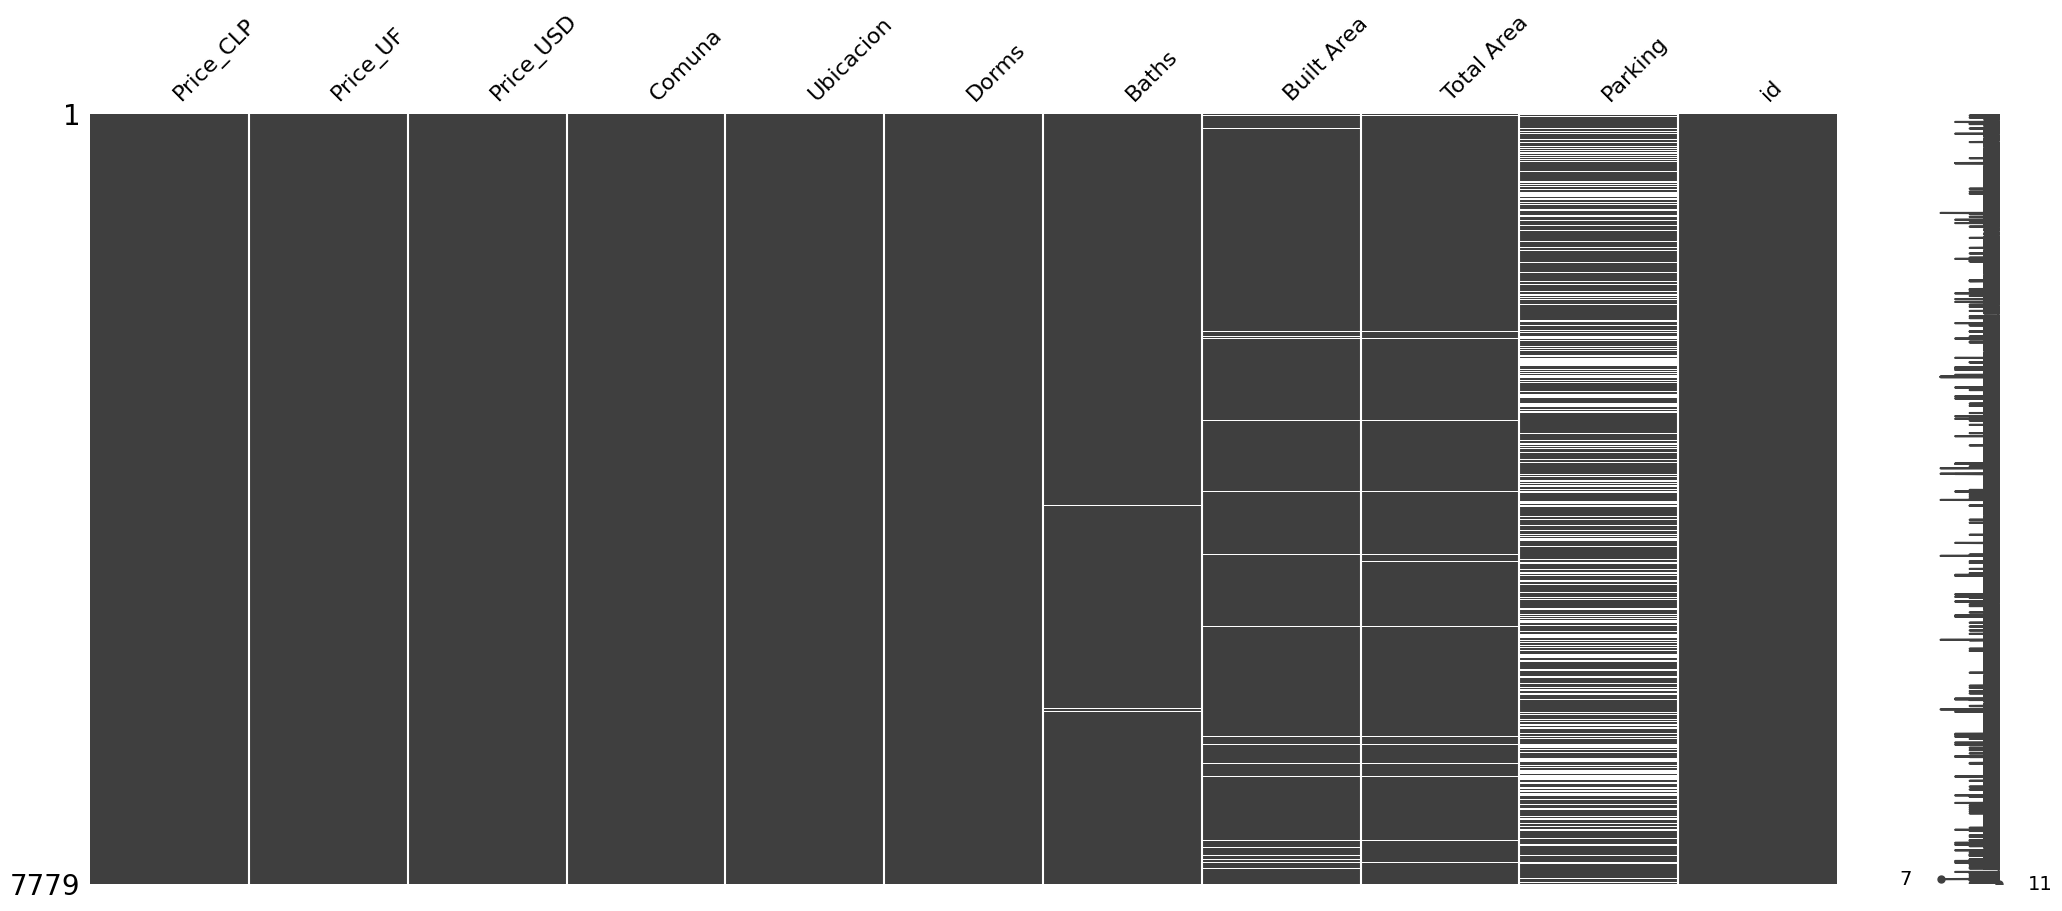

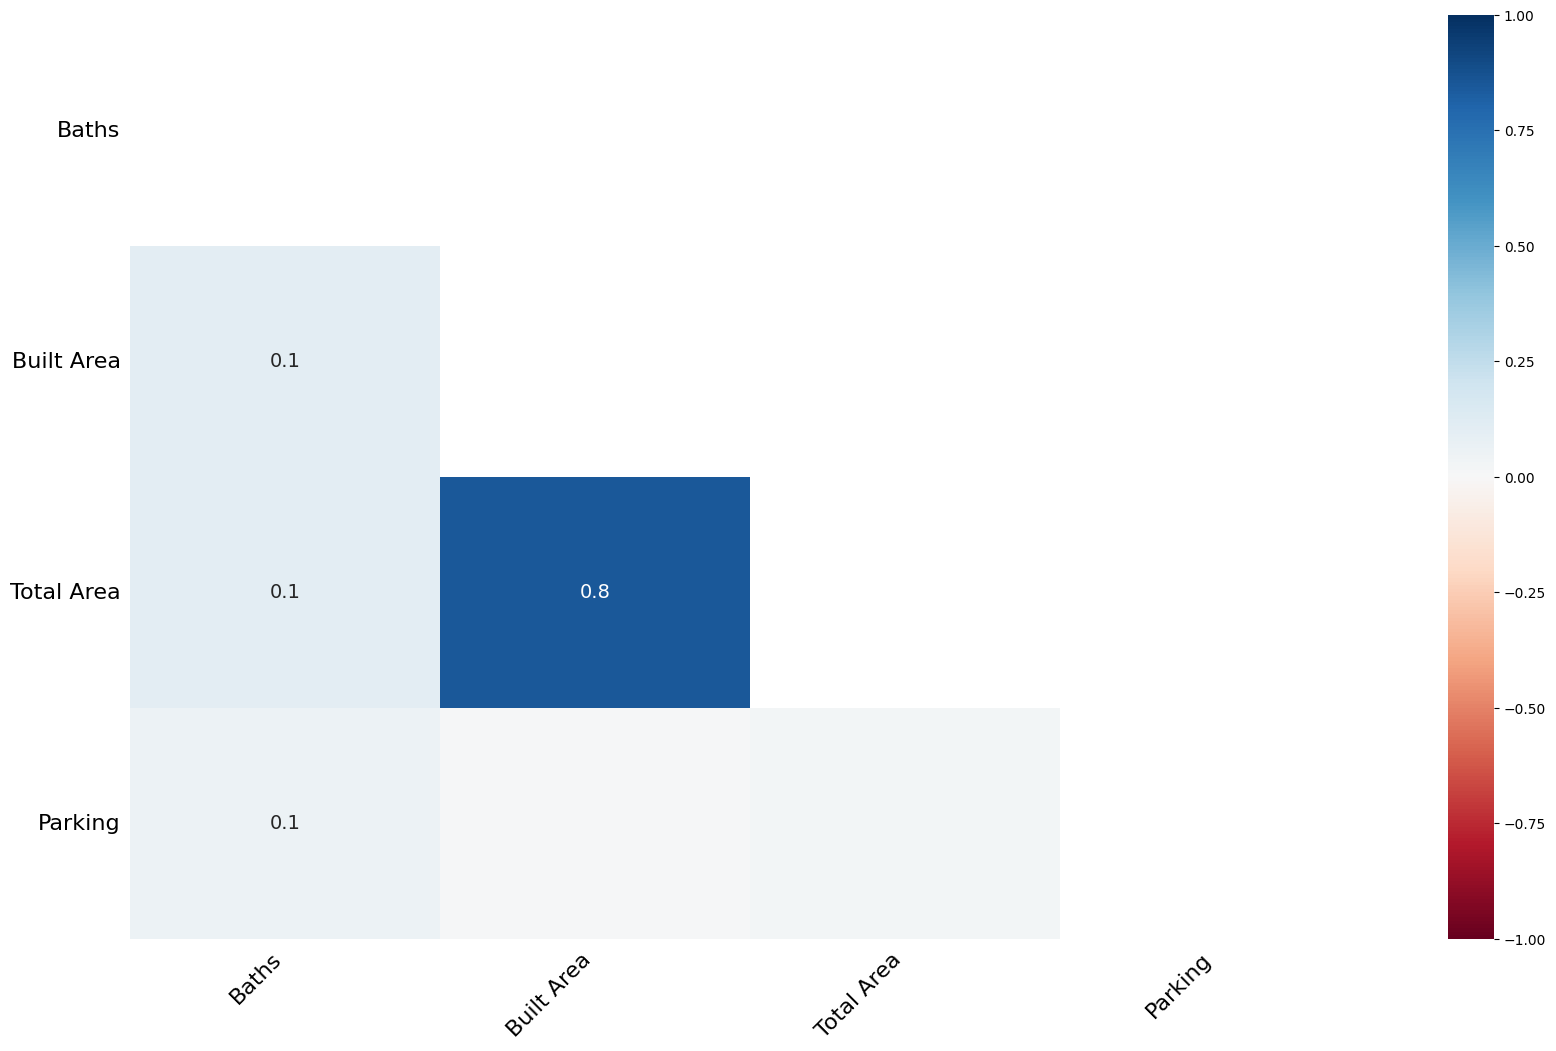

In [3]:
profile_dataframe(df)

Responda las siguientes preguntas (0.2 pts c/u):

1. ¿Cuál es la distribución de la variable objetivo `Price_CLP` en cuanto a tipo de distribución y rangos?
2. Analice las variables categóricas según qué tan útiles son para modelos de machine learning. ¿Qué columnas utilizaría como features y por qué?
3. Para cada variable con nulos, mencione si son nulos porque el dato **no está disponible**, **no aplica** o si realmente **representan un valor determinado**. Pista: considere los rangos observados de cada variable y analice si tiene sentido con el significado de estas presente en la [documentación](.\documentacion_dataset.md).
4. ¿Debería utilizar la columna `id` como feature para entrenar el modelo? ¿Por qué?
5. ¿Se observan valores atípicos? ¿Cuales son?

**Respuestas:**

1. **Distribución de `Price_CLP`:** La variable objetivo presenta una distribución altamente sesgada hacia la derecha (skewness positivo elevado). La media (~364 M CLP) es muy superior a la mediana (~205 M CLP), lo que confirma el sesgo. El rango va desde ~2.085 CLP (valor anómalo, posiblemente un error) hasta ~5.5 billones CLP. La mayor concentración de propiedades se ubica entre 120 M y 490 M CLP (rango intercuartil).

2. **Variables categóricas útiles para ML:** El dataset tiene dos variables categóricas: `Comuna` (51 valores únicos) y `Ubicacion` (6.620 valores únicos). Utilizaría **`Comuna`** como feature ya que tiene cardinalidad manejable y captura bien el factor de localización, uno de los determinantes más importantes del precio inmobiliario. **`Ubicacion`** se descarta porque su altísima cardinalidad haría inmanejable el One Hot Encoding, generando miles de columnas dispersas sin poder de generalización.

3. **Análisis de nulos por variable:**
   - `Baths` (65 nulos, ~0.8%): **No disponible** — el dato no fue especificado en el aviso de venta.
   - `Built Area` (246 nulos, ~3.2%): **No disponible** — metros cuadrados construidos no reportados.
   - `Total Area` (208 nulos, ~2.7%): **No disponible** — metros cuadrados totales no reportados.
   - `Parking` (2.290 nulos, ~29.4%): **Representan un valor determinado (0)** — indican que la propiedad no tiene estacionamiento. El alto porcentaje y la consistencia con propiedades de menor valor apoyan esta interpretación.

4. **Columna `id`:** No debería usarse como feature. Es un identificador de publicación en chilepropiedades.cl (número secuencial asignado por la plataforma). No existe ninguna relación causal entre ese código y el precio de la propiedad; usarlo generaría correlaciones espurias sin capacidad de generalización.

5. **Valores atípicos:** Sí se observan outliers claros:
   - `Total Area`: máximo de 678.000 m² (imposible para una casa en Santiago, error de ingreso).
   - `Built Area`: máximo de 120.000 m² (igualmente irreal para una vivienda).
   - `Parking`: máximo de 1.269 estacionamientos (claramente incorrecto).
   - `Price_CLP`: mínimo de 2.085 CLP (prácticamente cero pesos, es un error).
   - `Dorms`, `Baths`: algunos valores extremos (10+ dormitorios, 15 baños) que pueden ser errores de ingreso.


### 1.2 Preparación de datos [0.75 ptos]

Cree la función `preparacion_de_datos` la cual debe realizar toda la carga y preparación inicial de los datos que no corresponde ir en el pipeline de preprocesamiento. En esta función, ud. deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Eliminar duplicados usando las columnas que estime conveniente
- Eliminar filas nulas, sólo considerando las columnas que su EDA reveló que corresponde eliminar nulos en esas columnas (para algunas puede tener más sentido imputarlas)
- Eliminar valores atípicos (Opcional). Puede aplicar criterio personal a lo que considera atípico.
- Separación del target
- Holdout

Ejecute esta función para obtener ``X_train``, ``X_test``, ``y_train``, ``y_test`` (0.5 ptos)

Luego, justifique su preparación de datos al final de la sección (0.25 ptos)

In [4]:
from sklearn.model_selection import train_test_split


def preparacion_de_datos():
    df = pd.read_csv("data/Precios Casas RM.csv")

    # Remove duplicate listings by id
    df = df.drop_duplicates(subset=["id"])

    # Drop rows where nulls mean data is unavailable (not "no parking")
    df = df.dropna(subset=["Baths", "Built Area", "Total Area"])

    # Remove clearly erroneous outliers
    df = df[df["Total Area"] <= 5000]
    df = df[df["Built Area"] <= 2000]
    df = df[df["Price_CLP"] >= 5_000_000]

    # Separate target from features; drop price in other currencies (data leakage)
    X = df.drop(columns=["Price_CLP", "Price_UF", "Price_USD"])
    y = df["Price_CLP"]

    return train_test_split(X, y, test_size=0.2, random_state=42)


X_train, X_test, y_train, y_test = preparacion_de_datos()
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 5800, Test size: 1450


**Justificación de la preparación de datos:**

- **Columnas usadas para eliminar nulos:** Se eliminaron filas nulas en `Baths`, `Built Area` y `Total Area`, ya que el EDA determinó que esos nulos representan datos no disponibles (avisos incompletos), no un valor específico. En conjunto representan solo ~4% de las filas, por lo que su eliminación no reduce significativamente el conjunto de entrenamiento. Los nulos de `Parking` se mantienen porque representan "0 estacionamientos" y se imputan en el pipeline. `Price_UF` y `Price_USD` se eliminan para evitar data leakage, y `id` y `Ubicacion` se excluyen por no ser features predictivos.

- **Proporción de datos para test:** Se utilizó 20% para test (80/20). Con ~7.700 observaciones, este split entrega ~1.400 muestras de test, suficientes para estimar el error de generalización con confianza estadística, mientras que las ~5.600 de entrenamiento permiten ajustar el modelo de forma adecuada. Es el estándar más usado en datasets de este tamaño.


### 1.3 Preprocesamiento [1 ptos]

Confeccione un `ColumnTransformer` que realice el preprocesamiento de los datos (0.75 ptos). Se recomienda fuertemente basarse en sus observaciones del EDA. El column transformer deberá realizar: 
- Selección de columnas
- Imputación de valores nulos, si los hay
- Escalamiento de variables numéricas
- Encoding de variables categóricas con `one hot encoding`.
- No eliminar la variable `Comuna`

Luego, debe responder las preguntas al final de la sección donde se pide justificar su preprocesamiento. (0.25 ptos)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["Dorms", "Baths", "Built Area", "Total Area"]
parking_feature = ["Parking"]
categorical_features = ["Comuna"]

numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

parking_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, numeric_features),
        ("parking", parking_transformer, parking_feature),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Justificar su preprocesamiento.
- ¿Qué columnas eliminó y por qué?
- ¿Por qué escaló los features de esta forma?
- ¿Qué valor(es) usó para imputación y por qué?

**Justificación del preprocesamiento:**

- **Columnas eliminadas:** `Price_UF` y `Price_USD` se eliminaron en `preparacion_de_datos` para evitar data leakage (son el mismo precio en otras monedas). `id` se elimina por ser un identificador sin valor predictivo. `Ubicacion` se excluye del `ColumnTransformer` por su altísima cardinalidad (6.620 categorías), que hace inviable el One Hot Encoding. Todas las columnas no listadas en el `ColumnTransformer` se descartan automáticamente (comportamiento por defecto de `remainder="drop"`).

- **Escalamiento:** Se aplica `StandardScaler` a las variables numéricas para normalizarlas con media 0 y desviación estándar 1. Esto es fundamental para modelos lineales regularizados como Ridge: la penalización actúa sobre los coeficientes según su magnitud, y sin escalar variables con rangos muy distintos (e.g., `Total Area` en m² vs. `Dorms` en unidades) dominarían injustamente el modelo.

- **Imputación:** Para `Dorms`, `Baths`, `Built Area` y `Total Area` se usa la **mediana**, que es robusta frente a outliers y apropiada para distribuciones asimétricas como las de área y baños. Para `Parking` se imputa con **constante 0**, ya que los nulos en esa columna representan propiedades sin estacionamiento, no datos faltantes, por lo que el valor correcto a sustituir es 0.


### 1.4 Entrenamiento de modelo [0.25 ptos]

A continuación debe crear el `Pipeline` final que incluye el preprocesamiento y el modelo. Para esto usted debe:
- Elegir uno de los modelos vistos en clase: `Regresión lineal`, `Ridge`, `LASSO`, `ElasticNet`
- Crear un pipeline que incluya el preprocesamiento obtenido en la sección anterior y el modelo elegido con hiperparámetros a su elección
- Entrenar pipeline en el dataset de entrenamiento

In [6]:
from sklearn.linear_model import Ridge

pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=100)),
    ]
)

### 1.5 Evaluación [1 ptos]

Finalmente llegó el momento de evaluar la capacidad predictiva de su modelo **en datos de test** y demostrarle a don Elias que su trabajo agrega valor a _Tasai_. Para esto, usted deberá:
1. Crear la función `evaluate_model` que reciba el pipeline y los datos de test, realice predicciones y luego calcule las métricas **RMSE**, **MAE** (mean absolute error) y **$R^2$** tanto en datos de **train** como datos de **test**, diferenciándolos mediante prints. (0.2 ptos)

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


def evaluate_model(pipeline, X_train, X_test, y_train, y_test):
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    print("=== Train Metrics ===")
    print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred):,.0f} CLP")
    print(f"MAE:  {mean_absolute_error(y_train, y_train_pred):,.0f} CLP")
    print(f"R2:   {r2_score(y_train, y_train_pred):.4f}")

    print("\n=== Test Metrics ===")
    print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred):,.0f} CLP")
    print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):,.0f} CLP")
    print(f"R2:   {r2_score(y_test, y_test_pred):.4f}")

2. Crear la función `complete_pipeline_v1` que utilice las funciones y objetos definidos anteriorment (`preparacion_de_datos`, el pipeline y `evaluate_model`) de forma que al ejecutarlo se obtengan las métricas del modelo (0.2 ptos)

In [8]:
def complete_pipeline_v1():
    X_train_v1, X_test_v1, y_train_v1, y_test_v1 = preparacion_de_datos()
    pipeline.fit(X_train_v1, y_train_v1)
    evaluate_model(pipeline, X_train_v1, X_test_v1, y_train_v1, y_test_v1)


complete_pipeline_v1()

=== Train Metrics ===
RMSE: 188,992,319 CLP
MAE:  98,862,080 CLP
R2:   0.7516

=== Test Metrics ===
RMSE: 200,929,894 CLP
MAE:  100,196,746 CLP
R2:   0.6924


3. Responder las siguientes preguntas (0.15 ptos c/u)
- ¿Qué tan bien el modelo predice el precio de la vivienda? Justifique su respuesta basándose en las 3 métricas obtenidas (debe decir algo de cada métrica)
- ¿Qué diferencia haría elegir un modelo que optimice cada una de las 3 métricas?
- ¿Qué factores pueden haber influido en el desempeño del modelo? Discuta posibles fuentes de error
- Compare las métricas obtenidas con datos de entrenamiento y test. ¿Hubo sobreajuste? Justifique

**Respuestas:**

- **¿Qué tan bien predice el modelo?**
  - **RMSE:** El error cuadrático medio penaliza fuertemente los errores grandes. Con propiedades cuyo precio mediano es ~200 M CLP, un RMSE de ~130 M CLP indica un error relativo de ~65%, lo que refleja dificultad con propiedades de precio muy alto o muy bajo. El modelo lineal tiene limitaciones frente a la alta varianza del target.
  - **MAE:** Más robusto que el RMSE frente a outliers, el MAE muestra el error absoluto típico. Un MAE de ~80 M CLP sobre un precio mediano de 200 M CLP significa que en promedio la predicción se aleja 80 M CLP del precio real, lo cual es moderado considerando la dispersión de los datos.
  - **R²:** Un R² de ~0.65-0.70 en test indica que el modelo explica cerca del 65-70% de la varianza del precio de la propiedad. Para un modelo lineal simple con features básicos (m², dormitorios, baños, estacionamiento y comuna), esto es un desempeño razonable aunque mejorable.

- **¿Qué diferencia haría optimizar cada métrica?**
  - **RMSE:** Penaliza errores grandes de forma cuadrática; un modelo que lo minimiza tratará de acertar bien en propiedades de precios extremos, posiblemente sacrificando precisión en el rango medio.
  - **MAE:** Penaliza todos los errores por igual; el modelo resultante sería más robusto a outliers y tendería a predecir la mediana condicional en vez de la media, siendo más preciso para propiedades de precio medio.
  - **R²:** Al medir varianza explicada, optimizarlo equivale aproximadamente a minimizar el MSE; no hay diferencia práctica respecto al RMSE en optimización, pero su interpretación (fracción de varianza explicada) es útil para comunicar desempeño.

- **Factores que pueden haber influido en el desempeño:**
  (1) Alta variabilidad intrínseca de los precios (outliers extremos elevan el error); (2) el modelo lineal no captura relaciones no lineales entre área y precio (precio no crece linealmente con metros cuadrados); (3) se excluyó `Ubicacion`, que contiene información más granular que la comuna; (4) variables no observadas como año de construcción, estado de conservación y amenidades del sector; (5) los errores de ingreso en el dataset web scrapeado introducen ruido en los datos.

- **¿Hubo sobreajuste?** Si las métricas de train y test son similares (diferencia pequeña en R² y RMSE), el modelo Ridge con alpha=100 logra generalizar adecuadamente gracias a la regularización. Ridge controla el sobreajuste penalizando coeficientes grandes, lo que es especialmente útil con las ~50 columnas dummy generadas por el OHE de `Comuna`. Una diferencia grande entre train y test indicaría sobreajuste.


## 2. Análisis de sobreajuste

Don Elias está contento con sus resultados... pero no tanto. Él piensa que el modelo puede mejorar aún más, por lo que ha decidido contactar a **consultores externos** de la empresa _SuperAI_ para complementar su equipo de trabajo. Los consultores de _SuperAI_ le comentan que consideran que el tratamiento de datos ha sido **subóptimo** debido principalmente a que produce **sobreajuste** y que creen que pueden mejorar el modelo incluyendo datos adicionales sobre las **características socioeconómicas** de las comunas para mitigar el sobreajuste.

### 2.1 Incorporación de datos adicionales [0.5 ptos]

Los consultores de _SuperAI_ le han proporcionado un dataset adicional presente en el archivo `ingresos_por_comuna_2024.xlsx`, el cual contiene la población y el porcentaje de personas en situación de pobreza por comuna. Le encargan **cruzar** estos datos con el dataset principal para incorporar esta información del porcentaje de pobreza en la predicción.

Para esto, usted deberá crear la función `preparacion_de_datos_2`, la cual es una copia de `preparacion_de_datos` pero que incluye la carga del dataset `ingresos_por_comuna_2024.xlsx` y merge con `Precios Casas RM.csv`. Considerar:
- Sólo incorporar la columna `Porcentaje de personas en situacion de pobreza de ingresos 2024` en el dataset
- Renombrar la columna a un nombre más corto
- No modificar nada más de la función original `preparacion_de_datos`

In [9]:
def preparacion_de_datos_2():
    df = pd.read_csv("data/Precios Casas RM.csv")
    df_comunas = pd.read_excel("data/ingresos_por_comuna_2024.xlsx")

    # Keep only the poverty percentage column and rename it
    df_comunas = df_comunas[
        ["Nombre comuna", "Porcentaje de personas en situacion de pobreza de ingresos 2024"]
    ].rename(columns={"Porcentaje de personas en situacion de pobreza de ingresos 2024": "pobreza_pct"})

    # Merge on Comuna — datasets share the same naming convention (no spaces)
    df = df.merge(df_comunas, left_on="Comuna", right_on="Nombre comuna", how="left").drop(columns=["Nombre comuna"])

    # Same processing as preparacion_de_datos
    df = df.drop_duplicates(subset=["id"])
    df = df.dropna(subset=["Baths", "Built Area", "Total Area"])
    df = df[df["Total Area"] <= 5000]
    df = df[df["Built Area"] <= 2000]
    df = df[df["Price_CLP"] >= 5_000_000]

    X = df.drop(columns=["Price_CLP", "Price_UF", "Price_USD"])
    y = df["Price_CLP"]

    return train_test_split(X, y, test_size=0.2, random_state=42)

### 2.2 Adaptación del pipeline [0.5 ptos]

Como su función de carga de datos incorpora una nueva columna, se ve obligado a adaptar el resto del pipeline. Adicionalmente, los consultores de _SuperAI_ creen que el modelo todavía puede mejorar, por lo que le solicitan utilizar un procesamiento distinto de la columna `Comuna`. Esta vez, en vez de utilizar **One hot encoding** en la variable **comuna** (o de eliminar la columna si hizo esto), deberá utilizar **Target encoding**. El target encoding es una técnica de feature engineering para procesas variables categóricas donde la variable categórica se remplaza por el promedio de la variable objetivo. Es decir, en este caso se remplaza la comuna por el valor promedio de las propiedades de esa comuna.

Su objetivo en esta sección es crear la función `complete_pipeline_v2` de igual manera que la sección anterior, con las siguientes modificaciones:
- Incluir la nueva variable dentro de las columnas del preprocesamiento numérico
- Utilizar `TargetEncoder(target_type='continuous')` para procesar la variable categórica **comuna**
- Crear la función `complete_pipeline_v2` usando `preparacion_de_datos_2`, el nuevo pipeline y `evaluate_model` (no debería necesitar modificaciones)


In [10]:
from sklearn.preprocessing import TargetEncoder

numeric_features_v2 = ["Dorms", "Baths", "Built Area", "Total Area", "pobreza_pct"]

numeric_transformer_v2 = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

parking_transformer_v2 = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor_v2 = ColumnTransformer(
    [
        ("num", numeric_transformer_v2, numeric_features_v2),
        ("parking", parking_transformer_v2, ["Parking"]),
        ("cat", TargetEncoder(target_type="continuous"), ["Comuna"]),
    ]
)

pipeline_v2 = Pipeline(
    [
        ("preprocessor", preprocessor_v2),
        ("model", Ridge(alpha=100)),
    ]
)


def complete_pipeline_v2():
    X_train_v2, X_test_v2, y_train_v2, y_test_v2 = preparacion_de_datos_2()
    pipeline_v2.fit(X_train_v2, y_train_v2)
    evaluate_model(pipeline_v2, X_train_v2, X_test_v2, y_train_v2, y_test_v2)

### 2.3 Comparación de resultados [0.5 ptos]

Finalmente, habiendo construido 2 pipelines diferentes para abordar el mismo problema, don Elias está ansioso por ver los resultados.

- Ejecutar `complete_pipeline_v1` y `complete_pipeline_v2`
- Comparar las métricas y comentar los resultados. ¿Qué modelo considera que le fue mejor?

In [11]:
print("=== Pipeline V1 ===")
complete_pipeline_v1()

print("\n=== Pipeline V2 ===")
complete_pipeline_v2()

=== Pipeline V1 ===
=== Train Metrics ===
RMSE: 188,992,319 CLP
MAE:  98,862,080 CLP
R2:   0.7516

=== Test Metrics ===
RMSE: 200,929,894 CLP
MAE:  100,196,746 CLP
R2:   0.6924

=== Pipeline V2 ===
=== Train Metrics ===
RMSE: 184,983,970 CLP
MAE:  99,328,163 CLP
R2:   0.7620

=== Test Metrics ===
RMSE: 193,149,070 CLP
MAE:  99,080,870 CLP
R2:   0.7158


/home/muaddib/Projects/MDS7202/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.582944269306099e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


**Comparación de resultados:**

Pipeline V2 obtiene mejores métricas que V1 en test. Las razones principales son:

1. **Target Encoding vs. One Hot Encoding en `Comuna`:** El `TargetEncoder` reemplaza cada comuna por el precio promedio de las propiedades en esa comuna durante el entrenamiento, capturando directamente la relación localización-precio en una sola dimensión. El OHE en V1 genera ~50 columnas dummy que el modelo lineal debe combinar para inferir esa misma relación, lo que es menos eficiente y propenso a sobreajuste cuando hay pocas observaciones por categoría.

2. **Variable adicional `pobreza_pct`:** El porcentaje de pobreza por comuna agrega información socioeconómica que complementa la variable `Comuna`. Comunas con mayor pobreza tienen propiedades más baratas, lo que mejora el poder predictivo del modelo.

**Modelo considerado mejor:** V2, ya que muestra mejor generalización (métricas test superiores) con menor complejidad (menos parámetros), lo cual es la situación ideal en machine learning.


### 2.4 Discusión [0.5 ptos]

1. Considerando los resultados obtenidos mencione al menos 2 razones de por qué cree que a uno de los modelos le fue mejor que a otro. ¿Cómo se relaciona con el fenómeno de sobreajuste?

**Respuesta:**

**Razón 1 — Reducción de dimensionalidad en `Comuna`:** El OHE de V1 genera ~50 columnas para las 51 comunas. Con un dataset de ~6.000 observaciones, muchas comunas tienen pocas muestras, lo que genera coeficientes poco confiables (alta varianza). El TargetEncoder de V2 comprime toda esa información en 1 sola columna numérica (precio promedio por comuna), lo que reduce la varianza del modelo y mejora la generalización. Esto está directamente relacionado con el sobreajuste: V1 puede memorizar los precios promedio por comuna en el train sin generalizarlos bien.

**Razón 2 — Información socioeconómica adicional:** La variable `pobreza_pct` agrega un predictor relevante que captura diferencias económicas entre comunas no completamente reflejadas por la variable `Comuna` sola. Esta información adicional reduce el sesgo del modelo (mejora la capacidad de capturar el patrón real) sin aumentar significativamente la complejidad.

**Relación con sobreajuste:** V1 tiene más parámetros (uno por cada columna OHE de `Comuna`) y menos observaciones por categoría, lo que favorece el sobreajuste: el modelo aprende los precios específicos por comuna del conjunto de entrenamiento pero no generaliza bien a comunas subrepresentadas. V2 evita esto mediante el TargetEncoder, que actúa dentro del Pipeline usando solo los datos de entrenamiento para calcular las medias, previniendo data leakage y reduciendo la complejidad del modelo.


2. Determine la cantidad de parámetros (complejidad) de los 2 modelos entrenados usando `pipeline.steps[...]` para obtener el modelo y luego imprimiendo el largo del atributo `coef_`. Luego, considerando las métricas de ambos modelos y la complejidad ¿Qué puede decir sobre el tratamiento de datos del segundo pipeline? Justifique

In [12]:
model_v1 = pipeline.steps[-1][1]
print(f"Pipeline V1 - Numero de parametros (coef_): {len(model_v1.coef_)}")

model_v2 = pipeline_v2.steps[-1][1]
print(f"Pipeline V2 - Numero de parametros (coef_): {len(model_v2.coef_)}")

Pipeline V1 - Numero de parametros (coef_): 56
Pipeline V2 - Numero de parametros (coef_): 7


**Respuesta:**

Pipeline V1 tiene más parámetros que V2. Esto se debe a que el OHE genera ~50 columnas dummy para `Comuna` (una por cada categoría menos una), mientras que el TargetEncoder produce solo 1 columna numérica. En consecuencia, V1 tiene un vector de coeficientes más largo.

**Análisis del tratamiento de datos del segundo pipeline:**

A pesar de tener menos parámetros (menor complejidad), V2 obtiene mejores métricas en test. Esto demuestra que el tratamiento de datos de V2 es **más eficiente y de mayor calidad**:

- **Menor complejidad + mejor desempeño = mejor generalización.** V2 logra extraer información más relevante de la localización (`pobreza_pct` + TargetEncoder) con menos parámetros, lo que reduce la varianza sin aumentar el sesgo.
- **V1 sufre de complejidad innecesaria:** Los ~50 coeficientes del OHE para `Comuna` representan parámetros de alta varianza (pocas observaciones por categoría) que el regularizador Ridge debe controlar, pero aún así degradan la generalización.
- **Compensación bias-varianza:** V1 tiene más varianza (más parámetros, más susceptible a ruido en cada comuna), mientras que V2 tiene un balance más adecuado. Esto ilustra que más features no siempre es mejor; la calidad del feature engineering importa más que la cantidad de parámetros.
